In [65]:
import pandas as pd

df = pd.read_csv('data/airbnb_listings_stockholm_detailed.csv')


print(df.shape)



(4955, 79)


In [66]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4955 entries, 0 to 4954
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            4955 non-null   int64  
 1   listing_url                                   4955 non-null   str    
 2   scrape_id                                     4955 non-null   int64  
 3   last_scraped                                  4955 non-null   str    
 4   source                                        4955 non-null   str    
 5   name                                          4955 non-null   str    
 6   description                                   4763 non-null   str    
 7   neighborhood_overview                         1780 non-null   str    
 8   picture_url                                   4955 non-null   str    
 9   host_id                                       4955 non-null   int64  
 10 

In [67]:
df.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [69]:
df = df[[
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "review_scores_rating",
    "number_of_reviews",
    "availability_365",
    "minimum_nights",
    "host_is_superhost"
]]

In [70]:
display(df.describe())
display(df["price"].head(10))

,accommodates,bedrooms,beds,bathrooms,review_scores_rating,number_of_reviews,availability_365,minimum_nights
count,4955.000000,4697.000000,3188.000000,3189.000000,4086.000000,4955.000000,4955.000000,4955.000000
mean,3.502523,1.717479,2.156838,1.287551,4.805999,32.499697,139.374773,7.131786
std,2.023216,1.392828,1.834678,1.091029,0.338684,72.974173,140.441034,24.807856
min,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,4.750000,1.500000,0.000000,1.000000
50%,3.000000,1.000000,2.000000,1.000000,4.910000,8.000000,86.000000,3.000000
75%,4.000000,2.000000,3.000000,1.500000,5.000000,27.500000,276.000000,5.000000
max,16.000000,50.000000,50.000000,50.000000,5.000000,1239.000000,365.000000,500.000000


0      $917.00
1      $450.00
2    $1,073.00
3      $779.00
4    $2,352.00
5    $1,126.00
6      $950.00
7      $751.00
8    $4,300.00
9    $1,218.00
Name: price, dtype: str

Måste städa den viktigaste kategorin från dollartecken. Bedrooms visar max 50 och min 0 = felaktigt. Samma med beds och bathrooms. Accomotates har max 16, låter mycket måste kolla upp. Men börjar med pris.

In [71]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [72]:
df["price"].describe()

count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64

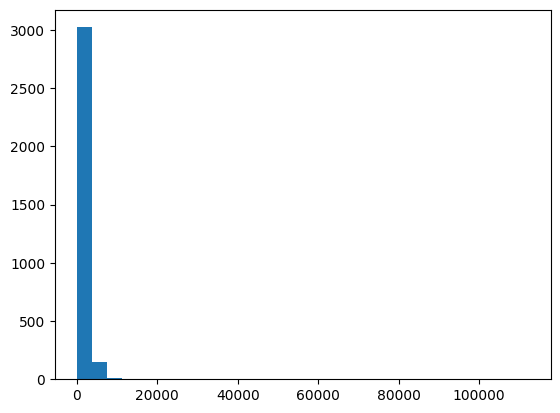

In [73]:
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=30)
plt.show()

Varför ser prisdatan så orimlig ut?

In [74]:
high = df["price"].sort_values(ascending=False).head(10)
low = df["price"].sort_values().head(10)

print("High prices:")
print(high)
print()
print("Low prices:")
print(low)

High prices:
2508    112218.0
2507    112218.0
2533    111984.0
2085     35000.0
2701     25000.0
2091     17872.0
3585     16000.0
2030     15000.0
114      15000.0
3285     12000.0
Name: price, dtype: float64

Low prices:
2271    120.0
2066    174.0
1834    190.0
2239    190.0
1374    198.0
524     200.0
732     200.0
527     200.0
2541    208.0
3668    210.0
Name: price, dtype: float64


Extrema skillnader i pris mellan högst och lägst, så höga priser per natt ser orimliga ut. Vill kolla in mer data på Outliers.

In [75]:
cheap_apt = df[df["price"] < 300][["price", "room_type", "accommodates", "beds", "neighbourhood_cleansed"]]
expensive_apt = df[df["price"] > 16000][["price", "room_type", "accommodates", "beds", "neighbourhood_cleansed"]]

print(cheap_apt)
print()
print(expensive_apt)

      price     room_type  accommodates  beds  neighbourhood_cleansed
30    262.0  Private room             4   3.0             Skärholmens
69    210.0  Private room             1   1.0  Hägersten-Liljeholmens
121   254.0  Private room             1   1.0  Hägersten-Liljeholmens
214   250.0  Private room             1   1.0              Skarpnäcks
290   241.0  Private room             1   1.0  Hägersten-Liljeholmens
...     ...           ...           ...   ...                     ...
4494  244.0   Shared room             1   2.0           Spånga-Tensta
4716  296.0  Private room             2   1.0          Rinkeby-Tensta
4717  285.0  Private room             1   1.0      Hässelby-Vällingby
4917  280.0  Private room             1   1.0                  Farsta
4951  272.0  Private room             2   1.0              Södermalms

[68 rows x 5 columns]

         price        room_type  accommodates  beds neighbourhood_cleansed
2085   35000.0  Entire home/apt             4   2.0          

De billiga lägenheterna verkar vara privata rum utanför staden så de är nog rimliga. Men de privata rummen för 112 218 kr kan man nog anta är felaktiga. Jag ser två saker nu, man borde förmodligen separera room_type för att få fram intressant data. Sedan verkar accommodates och beds inte lira så bra ihop, så jag vill kika på vilken av de två man kan lita på.

In [76]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,2540.0,1781.735433,1562.836297,210.0,900.0,1386.0,2250.00,35000.0
Hotel room,1.0,303.000000,NaN,303.0,303.0,303.0,303.00,303.0
Private room,621.0,1374.236715,7770.818047,120.0,394.0,597.0,969.00,112218.0
Shared room,28.0,474.892857,294.857698,244.0,291.5,366.0,508.75,1312.0



1 hotel room = ta bort.  Private room får uppenbarligen fel mean pga den höga outliern. Så, låt oss ta bort dem och testa igen!

In [77]:
df = df[df["price"] < 100000]

In [78]:
df.groupby("room_type")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,2540.0,1781.735433,1562.836297,210.0,900.00,1386.0,2250.00,35000.0
Hotel room,1.0,303.000000,NaN,303.0,303.00,303.0,303.00,303.0
Private room,618.0,836.538835,857.047373,120.0,393.25,597.0,957.50,10000.0
Shared room,28.0,474.892857,294.857698,244.0,291.50,366.0,508.75,1312.0


Efter att extrema värden filtrerats bort framträder tydliga skillnader mellan olika typer av boenden. Entire home/apt är generellt dyrast, följt av Private room, medan Shared room är billigast. Detta visar att room_type är en av de viktigaste faktorerna som påverkar priset.
Låt oss undersöka lite om det finns knasigheter mellan accomodates och beds. Rimligtvis borde antal sängar öka med större kapacitet för boende.

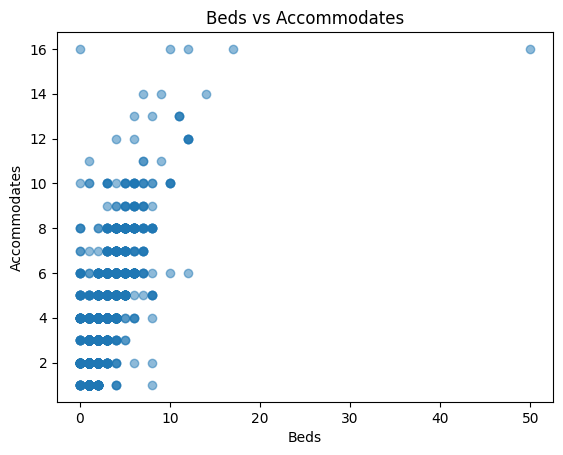

In [79]:
import matplotlib.pyplot as plt

plt.scatter(df["beds"], df["accommodates"], alpha=0.5)
plt.xlabel("Beds")
plt.ylabel("Accommodates")
plt.title("Beds vs Accommodates")
plt.show()

Scatterplotten visar ett tydligt positivt samband mellan beds och accommodates, men också flera avvikande värden och inkonsekvenser, såsom orimligt många sängar eller inga sängar alls. Detta tyder på brister i datakvaliteten för variabeln beds.

Variabeln accommodates bedöms därför vara mer tillförlitlig, eftersom den direkt representerar hur många gäster ett boende är avsett för.

Datasetet saknar dessutom en direkt variabel för fysisk storlek, såsom kvadratmeter, vilket innebär att accommodates används som ett indirekt mått på storlek i den fortsatta analysen.


Nu vill jag kika lite på kolumner med tomma värden!

In [80]:
df.isnull().sum()

price                       0
accommodates                0
bedrooms                   12
beds                        2
bathrooms                   1
room_type                   0
property_type               0
neighbourhood_cleansed      0
review_scores_rating      524
number_of_reviews           0
availability_365            0
minimum_nights              0
host_is_superhost          20
dtype: int64

In [81]:
df["host_is_superhost"] = df["host_is_superhost"].map({"t": 1, "f": 0})
df["host_is_superhost"] = df["host_is_superhost"].fillna(0)

Variabeln host_is_superhost innehöll kategoriska värden (“t” och “f”) och konverterades till numeriska värden för att underlätta analys. Saknade värden antogs motsvara icke-superhost.

Slutsats inför vidare analyser. Variablarna jag ser som mest intressanta är price, accommodates, room_type (sortera), neighbourhood, ratings vore ju bra kan man tycka, men 516 rader är tomma där. Isåfall måste jag lösa situationen med lägenheter som saknar ratings om man ska använda den variabeln.

In [82]:
#Tar bort hotellrummet och kategorin beds (går efter accommodates istället)
df = df[df["room_type"] != "Hotel room"]
df = df.drop(columns=["beds"])